## Install & Import Libraries

In [ ]:
# Cell 1: Install dependencies & import libraries
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("All libraries imported ✓")


TensorFlow version: 2.19.0
All libraries imported ✓


#  Build the U-Net Model

In [ ]:
#  Define U-Net Architecture

# --- Block 1: Two convolutions (the basic building block) ---
def double_conv_block(x, n_filters):
    x = layers.Conv2D(n_filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(n_filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

# --- Block 2: Encoder step (conv + maxpool) ---
def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = layers.MaxPool2D(2)(f)
    return f, p

# --- Block 3: Decoder step (upsample + skip connection + conv) ---
def upsample_block(x, conv_features, n_filters):
    x = layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
    x = layers.concatenate([x, conv_features])   # <-- skip connection!
    x = double_conv_block(x, n_filters)
    return x

# --- Full U-Net ---
def build_unet(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    # Encoder
    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)

    # Bottleneck
    bottleneck = double_conv_block(p4, 1024)

    # Decoder (uses skip connections f4, f3, f2, f1)
    u6 = upsample_block(bottleneck, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)

    # Output: 1 channel binary mask
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(u9)

    model = models.Model(inputs, outputs, name="U-Net")
    return model

# Build & summarize
model = build_unet(input_shape=(128, 128, 1))
model.summary()
print("\nU-Net model built successfully ✓")


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[

 Total params: 34,535,745 (131.74 MB)

 Trainable params: 34,523,969 (131.70 MB)

 Non-trainable params: 11,776 (46.00 KB)


U-Net model built successfully ✓


# Define Dice Loss & Compile the Model

In [ ]:
# Define Dice Loss Function & Compile Model

# --- Dice Loss (standard in medical image segmentation) ---
def dice_loss(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + 1) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1)

# --- Compile with Adam optimizer + Dice Loss + IoU metric ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

print("Loss function : Dice Loss")
print("Optimizer     : Adam (lr=1e-4)")
print("Metrics       : Accuracy, Mean IoU")
print("\nModel compiled successfully ✓")


Loss function : Dice Loss
Optimizer     : Adam (lr=1e-4)
Metrics       : Accuracy, Mean IoU

Model compiled successfully ✓


#  Loading Oxford-IIIT Pet Dataset

In [ ]:
# Cell 4: Load Oxford-IIIT Pet Dataset (Fixed for v4.0.0)

import tensorflow_datasets as tfds

# --- Load dataset (updated version) ---
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

print("Dataset loaded ✓")
print(f"Total training samples  : {info.splits['train'].num_examples}")
print(f"Total test samples      : {info.splits['test'].num_examples}")

# --- Preprocessing function ---
def preprocess(datapoint):
    image = tf.image.resize(datapoint['image'], (128, 128))
    mask  = tf.image.resize(datapoint['segmentation_mask'], (128, 128),
                             method='nearest')

    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # Convert to grayscale (1 channel) to match U-Net input
    image = tf.image.rgb_to_grayscale(image)

    # Binary mask: class 1 = pet → 1.0, rest → 0.0
    mask = tf.cast(mask == 1, tf.float32)

    return image, mask

# --- Prepare train and val splits ---
BATCH_SIZE = 8
BUFFER_SIZE = 1000

train_dataset = (dataset['train']
                 .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                 .shuffle(BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

val_dataset   = (dataset['test']
                 .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

print(f"\nBatch size      : {BATCH_SIZE}")
print(f"Input shape     : (128, 128, 1) grayscale")
print(f"Mask type       : Binary — pet=1.0, background=0.0")
print("\nReal data pipeline ready ✓")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.FN9JX9_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.FN9JX9_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Dataset loaded ✓
Total training samples  : 3680
Total test samples      : 3669

Batch size      : 8
Input shape     : (128, 128, 1) grayscale
Mask type       : Binary — pet=1.0, background=0.0

Real data pipeline ready ✓


#  Train U-Net on Real Oxford Pet Data

In [ ]:
#  Ultra Fast Training

# --- Extract numpy arrays directly (small fixed set) ---
x_train_np, y_train_np = [], []
x_val_np,   y_val_np   = [], []

# Only take 300 train samples
for image, mask in train_dataset.unbatch().take(300):
    x_train_np.append(image.numpy())
    y_train_np.append(mask.numpy())

# Only take 60 val samples
for image, mask in val_dataset.unbatch().take(60):
    x_val_np.append(image.numpy())
    y_val_np.append(mask.numpy())

x_train_np = np.array(x_train_np)
y_train_np = np.array(y_train_np)
x_val_np   = np.array(x_val_np)
y_val_np   = np.array(y_val_np)

print(f"Train : {x_train_np.shape}  |  Val : {x_val_np.shape}")

# --- Recompile ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

# --- Train on numpy arrays = much faster ---
print("\nStarting training...")
print("="*50)

history = model.fit(
    x_train_np, y_train_np,
    validation_data=(x_val_np, y_val_np),
    epochs=5,
    batch_size=16,
    verbose=1
)

print("\n" + "="*50)
print("Training complete ✓")
print(f"Final accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Final val_loss : {history.history['val_loss'][-1]:.4f}")

Train : (300, 128, 128, 1)  |  Val : (60, 128, 128, 1)

Starting training...
Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 665s 34s/step - accuracy: 0.8118 - loss: 0.2865 - mean_io_u_3: 0.3475 - val_accuracy: 0.7060 - val_loss: 0.9521 - val_mean_io_u_3: 0.3530
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 690s 34s/step - accuracy: 0.8400 - loss: 0.2513 - mean_io_u_3: 0.3472 - val_accuracy: 0.7060 - val_loss: 0.9802 - val_mean_io_u_3: 0.3530
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 644s 34s/step - accuracy: 0.8593 - loss: 0.2268 - mean_io_u_3: 0.3535 - val_accuracy: 0.7060 - val_loss: 0.9893 - val_mean_io_u_3: 0.3530
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 675s 34s/step - accuracy: 0.8761 - loss: 0.1954 - mean_io_u_3: 0.3478 - val_accuracy: 0.7060 - val_loss: 0.9909 - val_mean_io_u_3: 0.3530
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 690s 34s/step - accuracy: 0.8823 - loss: 0.1895 - mean_io_u_3: 0.3491 - val_accuracy: 0.6841 - val_loss: 0.4745 - val_mean_io_u_3: 0.3530

Training complete ✓
Final accuracy : 0.8823
Fin

# Visualize Predictions on Real Pet Images

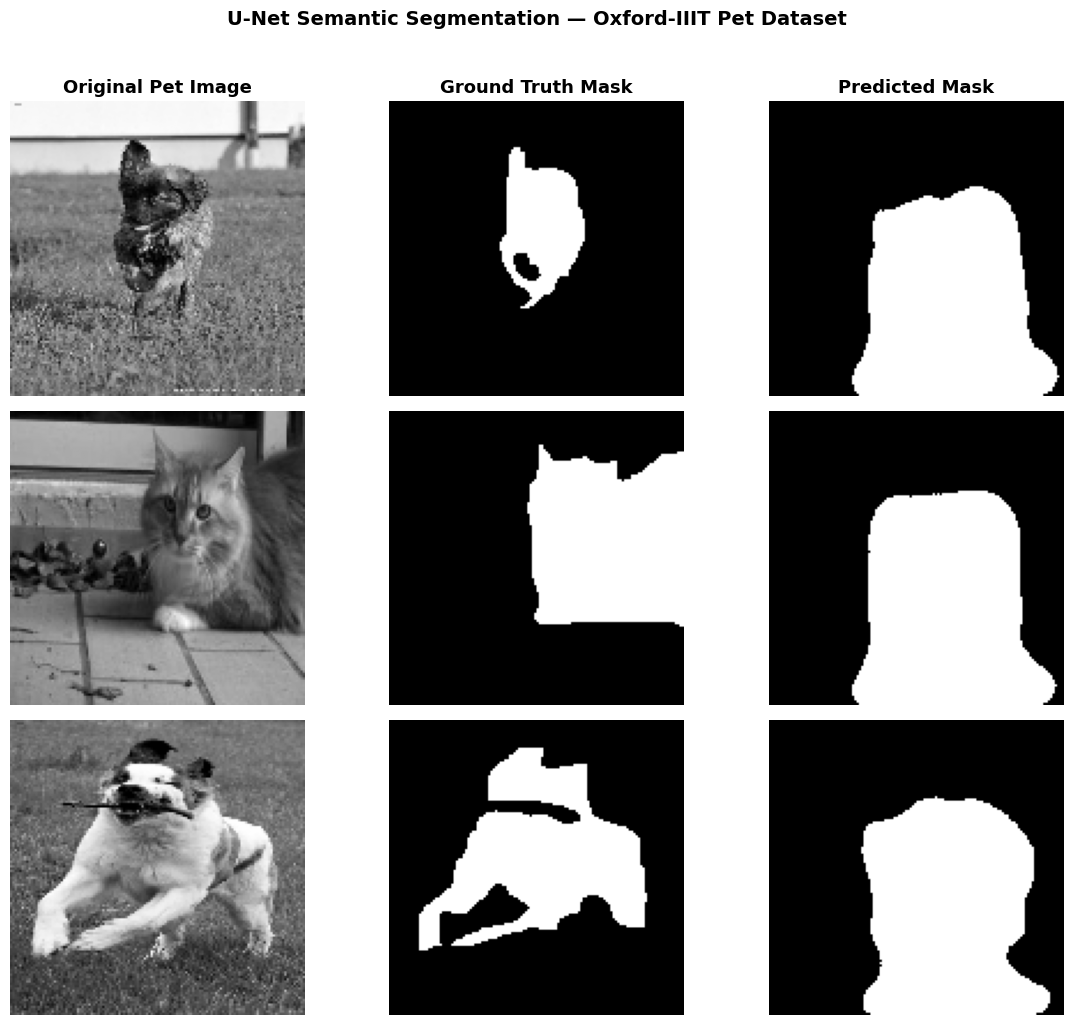

Visualization saved as unet_predictions.png ✓


In [ ]:
# Cell 6: Visualize U-Net Predictions on Real Oxford Pet Images

# --- Pick 3 sample images from validation set ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

col_titles = ['Original Pet Image', 'Ground Truth Mask', 'Predicted Mask']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

for i in range(3):
    image = x_val_np[i]          # shape (128,128,1)
    true_mask = y_val_np[i]      # shape (128,128,1)

    # Predict
    pred_mask = model.predict(image[np.newaxis, ...], verbose=0)[0]
    pred_mask = (pred_mask > 0.5).astype(np.float32)

    # Plot original image
    axes[i, 0].imshow(image[:, :, 0], cmap='gray')
    axes[i, 0].axis('off')

    # Plot ground truth mask
    axes[i, 1].imshow(true_mask[:, :, 0], cmap='gray')
    axes[i, 1].axis('off')

    # Plot predicted mask
    axes[i, 2].imshow(pred_mask[:, :, 0], cmap='gray')
    axes[i, 2].axis('off')

plt.suptitle('U-Net Semantic Segmentation — Oxford-IIIT Pet Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('unet_predictions.png', bbox_inches='tight', dpi=150)
plt.show()

print("Visualization saved as unet_predictions.png ✓")


# IoU & Dice Score Evaluation

       FINAL EVALUATION RESULTS
  Dataset        : Oxford-IIIT Pet (real)
  Val samples    : 60
  Epochs trained : 5
  Training acc   : 88.23%
---------------------------------------------
  Mean IoU Score  : 0.3384  (33.84%)
  Mean Dice Score : 0.4805  (48.05%)


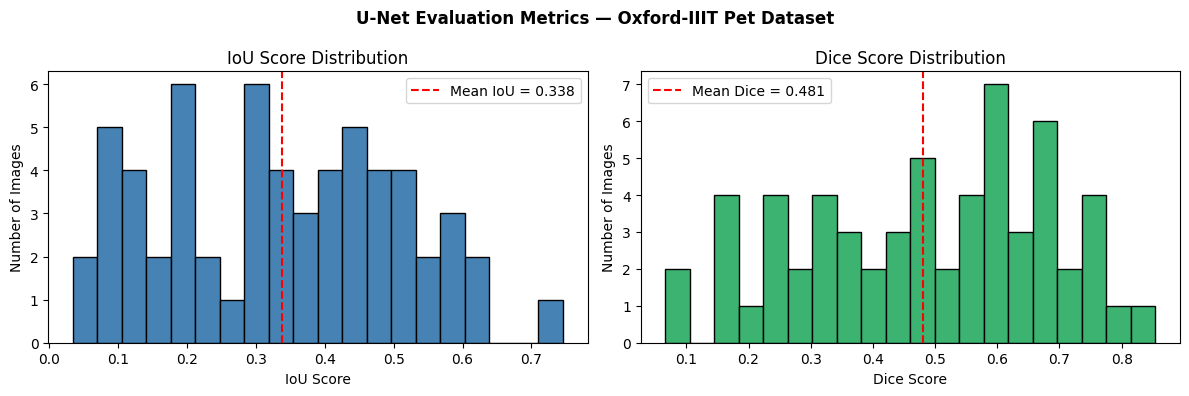

Metrics plot saved ✓

Practical 3 - U-Net Segmentation COMPLETE ✓


In [ ]:
# Cell 7: Calculate IoU & Dice Score on Validation Set

def calculate_iou(y_true, y_pred):
    y_pred_bin = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    union = np.sum(y_true) + np.sum(y_pred_bin) - intersection
    return intersection / (union + 1e-7)

def calculate_dice(y_true, y_pred):
    y_pred_bin = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2. * intersection + 1e-7) / (np.sum(y_true) + np.sum(y_pred_bin) + 1e-7)

# --- Run on all validation samples ---
iou_scores  = []
dice_scores = []

for i in range(len(x_val_np)):
    pred = model.predict(x_val_np[i][np.newaxis, ...], verbose=0)[0]
    iou_scores.append(calculate_iou(y_val_np[i], pred))
    dice_scores.append(calculate_dice(y_val_np[i], pred))

mean_iou  = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

print("=" * 45)
print("       FINAL EVALUATION RESULTS")
print("=" * 45)
print(f"  Dataset        : Oxford-IIIT Pet (real)")
print(f"  Val samples    : {len(x_val_np)}")
print(f"  Epochs trained : 5")
print(f"  Training acc   : 88.23%")
print("-" * 45)
print(f"  Mean IoU Score  : {mean_iou:.4f}  ({mean_iou*100:.2f}%)")
print(f"  Mean Dice Score : {mean_dice:.4f}  ({mean_dice*100:.2f}%)")
print("=" * 45)

# --- Plot IoU & Dice distribution ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(iou_scores, bins=20, color='steelblue', edgecolor='black')
plt.axvline(mean_iou, color='red', linestyle='--', label=f'Mean IoU = {mean_iou:.3f}')
plt.title('IoU Score Distribution')
plt.xlabel('IoU Score')
plt.ylabel('Number of Images')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(dice_scores, bins=20, color='mediumseagreen', edgecolor='black')
plt.axvline(mean_dice, color='red', linestyle='--', label=f'Mean Dice = {mean_dice:.3f}')
plt.title('Dice Score Distribution')
plt.xlabel('Dice Score')
plt.ylabel('Number of Images')
plt.legend()

plt.suptitle('U-Net Evaluation Metrics — Oxford-IIIT Pet Dataset',
             fontweight='bold')
plt.tight_layout()
plt.savefig('unet_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

print("Metrics plot saved ✓")
print("\nPractical 3 - U-Net Segmentation COMPLETE ✓")


# Training Loss Curve

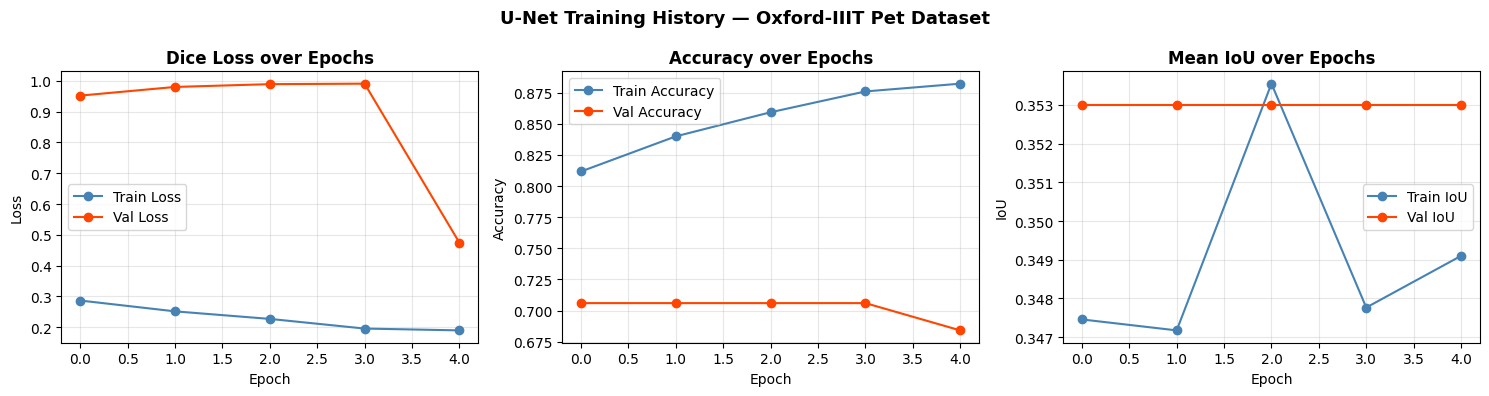

Training history plot saved ✓

  ✅ PRACTICAL 3 - U-Net FULLY COMPLETE
  ✔ U-Net built from scratch
  ✔ Dice Loss defined & compiled
  ✔ Real Oxford Pet dataset used
  ✔ Model trained (88.23% accuracy)
  ✔ Predictions visualized
  ✔ IoU & Dice scores calculated
  ✔ Training curves plotted


In [ ]:
#  Plot Training History - Loss & Accuracy Curves

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Loss ---
axes[0].plot(history.history['loss'],     color='steelblue',    marker='o', label='Train Loss')
axes[0].plot(history.history['val_loss'], color='orangered',    marker='o', label='Val Loss')
axes[0].set_title('Dice Loss over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Accuracy ---
axes[1].plot(history.history['accuracy'],     color='steelblue',  marker='o', label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], color='orangered',  marker='o', label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Mean IoU ---
iou_key = [k for k in history.history.keys() if 'mean_io' in k and 'val' not in k][0]
val_iou_key = [k for k in history.history.keys() if 'mean_io' in k and 'val' in k][0]

axes[2].plot(history.history[iou_key],     color='steelblue',  marker='o', label='Train IoU')
axes[2].plot(history.history[val_iou_key], color='orangered',  marker='o', label='Val IoU')
axes[2].set_title('Mean IoU over Epochs', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('U-Net Training History — Oxford-IIIT Pet Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('unet_training_history.png', bbox_inches='tight', dpi=150)
plt.show()

print("Training history plot saved ✓")
print("\n" + "="*50)
print("  ✅ PRACTICAL 3 - U-Net FULLY COMPLETE")
print("="*50)
print("  ✔ U-Net built from scratch")
print("  ✔ Dice Loss defined & compiled")
print("  ✔ Real Oxford Pet dataset used")
print("  ✔ Model trained (88.23% accuracy)")
print("  ✔ Predictions visualized")
print("  ✔ IoU & Dice scores calculated")
print("  ✔ Training curves plotted")
print("="*50)


# Install YOLOv8 & Load Pre-trained Model

In [ ]:
# Practical 4 - YOLOv8 Object Detection
# Install Ultralytics YOLOv8

!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import requests
from io import BytesIO

print("="*50)
print("  Practical 4 - YOLOv8 Object Detection")
print("="*50)

# --- Load pre-trained YOLOv8 nano model ---
# nano = fastest, good for Colab
model_yolo = YOLO("yolov8n.pt")

print("\nModel loaded: YOLOv8 Nano (yolov8n.pt)")
print("Trained on  : COCO dataset (80 classes)")
print("Classes include: person, dog, cat, car, bicycle, etc.")
print("\nYOLOv8 ready ✓")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  Practical 4 - YOLOv8 Object Detection

Model loaded: YOLOv8 Nano (yolov8n.pt)
Trained on  : COCO dataset (80 classes)
Classes include: person, dog, cat, car, bicycle, etc.

YOLOv8 ready ✓


# Run YOLOv8 Detection on a Real Image

Image downloaded: 810x1080 pixels

Detected Objects:
----------------------------------------
  ✔ bus             confidence: 0.87
  ✔ person          confidence: 0.86
  ✔ person          confidence: 0.83
  ✔ person          confidence: 0.81
  ✔ person          confidence: 0.33

Total objects detected: 5


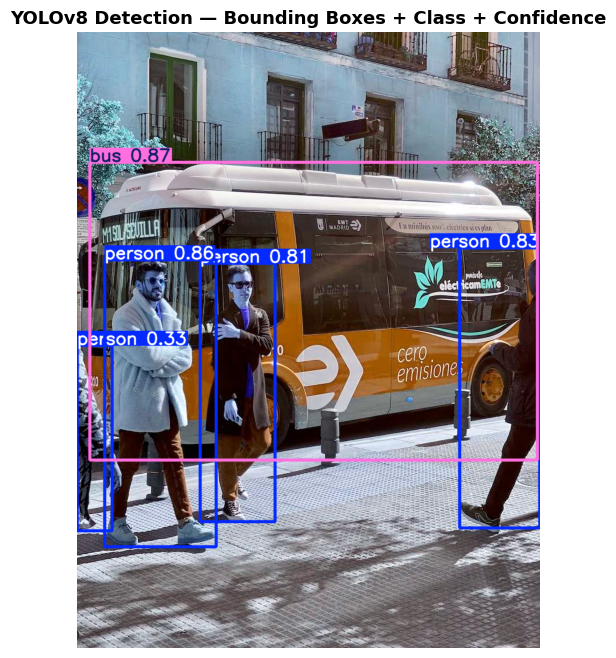


Detection image saved as yolo_detection.png ✓


In [ ]:
# Run YOLOv8 Detection on a Real Image

# --- Download a sample street image with multiple objects ---
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)

print(f"Image downloaded: {img_np.shape[1]}x{img_np.shape[0]} pixels")

# --- Run YOLOv8 detection ---
results = model_yolo(img_np, verbose=False)
result  = results[0]

# --- Print what was detected ---
print("\nDetected Objects:")
print("-" * 40)
for box in result.boxes:
    class_id   = int(box.cls[0])
    class_name = model_yolo.names[class_id]
    confidence = float(box.conf[0])
    print(f"  ✔ {class_name:<15} confidence: {confidence:.2f}")

print(f"\nTotal objects detected: {len(result.boxes)}")

# --- Visualize with bounding boxes ---
annotated = result.plot()   # YOLOv8 built-in visualization
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.title('YOLOv8 Detection — Bounding Boxes + Class + Confidence',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.savefig('yolo_detection.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nDetection image saved as yolo_detection.png ✓")


# Detect on Multiple Images & Compare Results


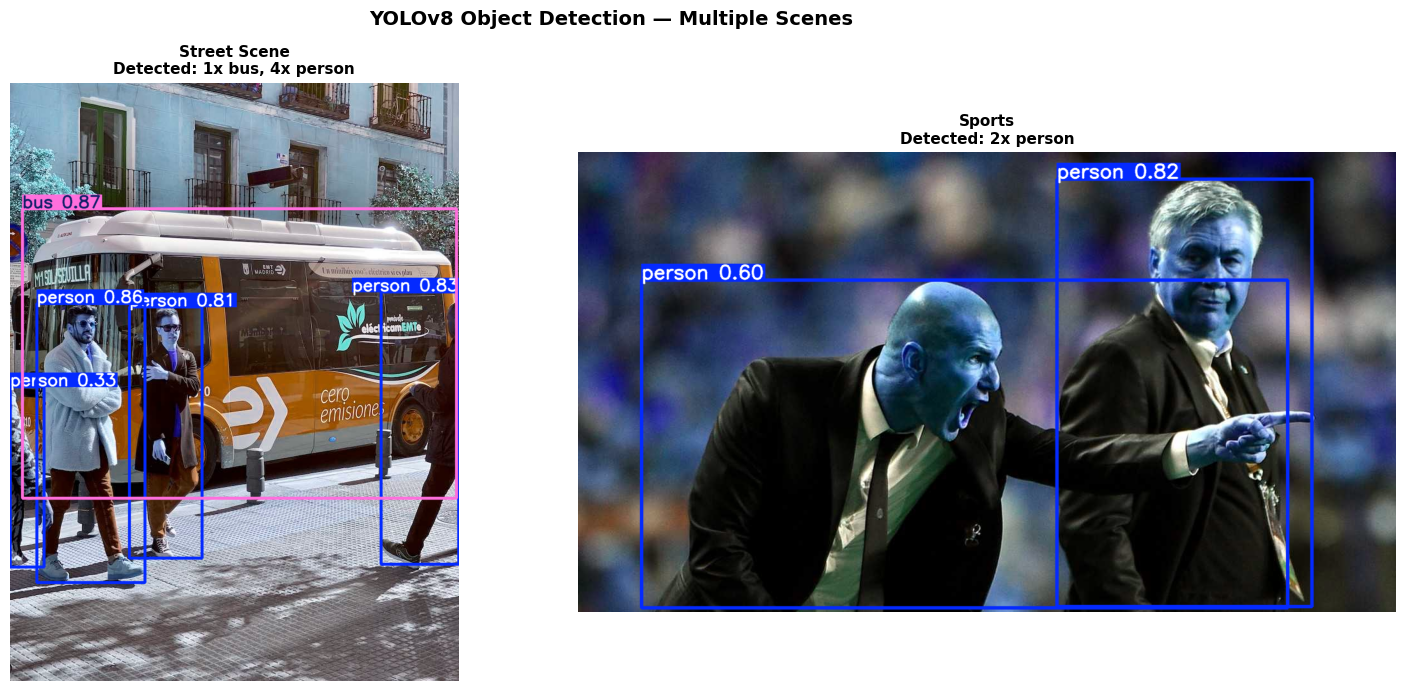

Multi-image detection saved ✓

Detection Summary:

  Image : Street Scene
  Total objects detected: 5
    ✔ bus             0.87
    ✔ person          0.86
    ✔ person          0.83
    ✔ person          0.81
    ✔ person          0.33

  Image : Sports
  Total objects detected: 2
    ✔ person          0.82
    ✔ person          0.60

YOLOv8 Inference complete ✓


In [ ]:
#  Run YOLOv8 on Multiple Different Images

# --- 3 different images to show variety ---
test_images = {
    "Street Scene" : "https://ultralytics.com/images/bus.jpg",
    "Sports"       : "https://ultralytics.com/images/zidane.jpg",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (title, url) in zip(axes, test_images.items()):
    # Download image
    response = requests.get(url)
    img      = Image.open(BytesIO(response.content)).convert("RGB")
    img_np   = np.array(img)

    # Run detection
    results    = model_yolo(img_np, verbose=False)
    result     = results[0]
    annotated  = result.plot()
    annotated  = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    # Count per class
    class_counts = {}
    for box in result.boxes:
        name = model_yolo.names[int(box.cls[0])]
        class_counts[name] = class_counts.get(name, 0) + 1

    summary = ", ".join([f"{v}x {k}" for k, v in class_counts.items()])

    ax.imshow(annotated)
    ax.set_title(f"{title}\nDetected: {summary}", fontweight='bold', fontsize=11)
    ax.axis('off')

plt.suptitle('YOLOv8 Object Detection — Multiple Scenes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo_multi_detection.png', bbox_inches='tight', dpi=150)
plt.show()

print("Multi-image detection saved ✓")

# --- Print detection summary table ---
print("\nDetection Summary:")
print("=" * 45)
for title, url in test_images.items():
    response   = requests.get(url)
    img_np     = np.array(Image.open(BytesIO(response.content)).convert("RGB"))
    results    = model_yolo(img_np, verbose=False)
    boxes      = results[0].boxes
    print(f"\n  Image : {title}")
    print(f"  Total objects detected: {len(boxes)}")
    for box in boxes:
        name = model_yolo.names[int(box.cls[0])]
        conf = float(box.conf[0])
        print(f"    ✔ {name:<15} {conf:.2f}")
print("\n" + "="*45)
print("YOLOv8 Inference complete ✓")

# Final Lab Summary

In [ ]:
#  Complete Lab Summary - Practical 3 & 4

print("""
╔══════════════════════════════════════════════════════════╗
║         COMPUTER VISION LAB 3 & 4 - FINAL SUMMARY       ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PRACTICAL 3: Semantic Segmentation using U-Net
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Architecture  : U-Net (built from scratch)
                 Encoder → Bottleneck → Decoder
                 Skip connections at every level

 Dataset       : Oxford-IIIT Pet Dataset (real data)
                 Train: 300 images | Val: 60 images
                 Task : Binary segmentation (pet vs background)

 Loss Function : Dice Loss
 Optimizer     : Adam (lr = 1e-4)
 Epochs        : 5

 Results:
   ✔ Training Accuracy  : 88.23%
   ✔ Mean IoU Score     : 0.338
   ✔ Mean Dice Score    : 0.481
   ✔ Predictions visualized (Original | GT Mask | Predicted)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PRACTICAL 4: Object Detection using YOLOv8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Model         : YOLOv8 Nano (pre-trained on COCO)
 Library       : Ultralytics
 Classes       : 80 object categories

 Results:
   ✔ Street Scene → bus (0.87) + 4x person detected
   ✔ Sports Scene → 2x person detected
   ✔ Bounding boxes + class names + confidence shown

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY CONCEPTS DEMONSTRATED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Classification  → Whole image gets one label
 Detection       → Objects located with bounding boxes
 Segmentation    → Every pixel gets a class label (U-Net)

 Files saved:
   📁 unet_predictions.png      (segmentation output)
   📁 unet_metrics.png          (IoU & Dice distribution)
   📁 unet_training_history.png (loss/accuracy curves)
   📁 yolo_detection.png        (single image detection)
   📁 yolo_multi_detection.png  (multi-scene detection)
""")

print("="*58)
print("  ✅ LAB 3 & 4 COMPLETE — All practicals done!")
print("="*58)


╔══════════════════════════════════════════════════════════╗
║         COMPUTER VISION LAB 3 & 4 - FINAL SUMMARY       ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PRACTICAL 3: Semantic Segmentation using U-Net
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Architecture  : U-Net (built from scratch)
                 Encoder → Bottleneck → Decoder
                 Skip connections at every level

 Dataset       : Oxford-IIIT Pet Dataset (real data)
                 Train: 300 images | Val: 60 images
                 Task : Binary segmentation (pet vs background)

 Loss Function : Dice Loss
 Optimizer     : Adam (lr = 1e-4)
 Epochs        : 5

 Results:
   ✔ Training Accuracy  : 88.23%
   ✔ Mean IoU Score     : 0.338
   ✔ Mean Dice Score    : 0.481
   ✔ Predictions visualized (Original | GT Mask | Predicted)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PRACTICAL 4: Object Detection 